<a href="https://colab.research.google.com/github/hsozpa/aidev/blob/main/%E6%9C%80%E7%B5%82%E8%AA%B2%E9%A1%8C_%E3%82%AA%E3%83%AA%E3%82%B8%E3%83%8A%E3%83%ABAI%E3%81%AE%E6%A7%8B%E7%AF%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf

from sklearn.model_selection import train_test_split

In [30]:
# データの読み込み
(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data()

In [31]:
# データの確認

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


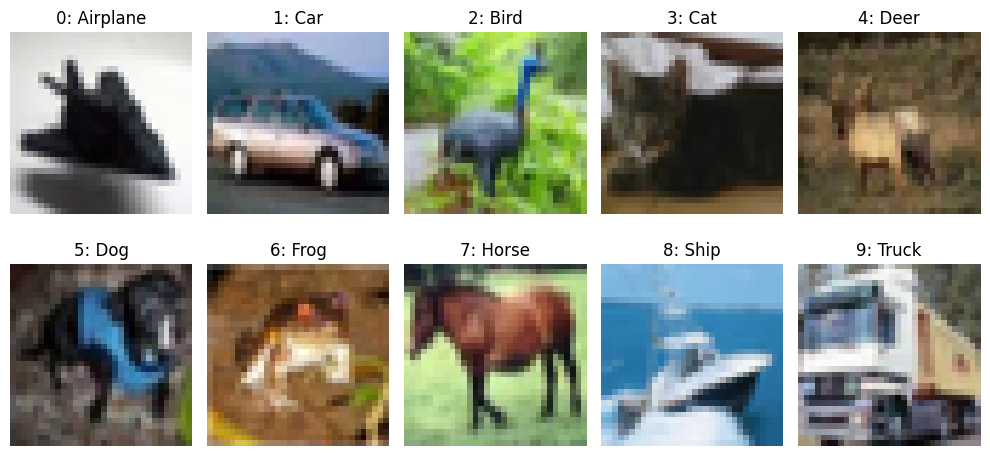

In [32]:
class_names = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

plt.figure(figsize=(10, 5))
for i, label in enumerate(range(10)):
    idx = np.where(Y_train.flatten() == label)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(f"{label}: {class_names[label]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [33]:
# データの前処理

# DeerとHorseを抽出
target_classes = [4, 7]
mask_train = np.isin(Y_train,target_classes)
mask_test = np.isin(Y_test, target_classes)

X = np.concatenate([X_train[mask_train.flatten()], X_test[mask_test.flatten()]])
Y = np.concatenate([Y_train[mask_train.flatten()], Y_test[mask_test.flatten()]])

#二値化
Y = np.where(Y == 4, 0, 1)
print(Y)

[[0]
 [1]
 [0]
 ...
 [1]
 [1]
 [1]]


In [34]:
# 正規化
X = X.astype("float32") / 255.0

In [35]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [36]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (5880, 1) , X_train= (5880, 32, 32, 3)
Y_valid= (2520, 1) , X_valid= (2520, 32, 32, 3)
Y_test= (3600, 1) , X_test= (3600, 32, 32, 3)


In [37]:
# モデルの初期化
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])


# モデルの構築
# model.compile(optimizer = "rmsprop", loss='categorical_crossentropy', metrics=['accuracy'])

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [38]:
# モデルの構造を表示
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
%%time
# 学習の実施
log = model.fit(
    X_train, Y_train,
    epochs=5000,
    batch_size=64,
    verbose=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            min_delta=0,
            patience=100,
            verbose=1,
            restore_best_weights=True
        )
    ],
    validation_data=(X_test, Y_test)
)

Epoch 1/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5839 - loss: 0.6782 - val_accuracy: 0.5172 - val_loss: 0.8790
Epoch 2/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7254 - loss: 0.5551 - val_accuracy: 0.7792 - val_loss: 0.4823
Epoch 3/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7812 - loss: 0.4704 - val_accuracy: 0.7228 - val_loss: 0.5459
Epoch 4/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8022 - loss: 0.4360 - val_accuracy: 0.8292 - val_loss: 0.3868
Epoch 5/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8284 - loss: 0.3854 - val_accuracy: 0.8086 - val_loss: 0.4158
Epoch 6/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8409 - loss: 0.3631 - val_accuracy: 0.8486 - val_loss: 0.3479
Epoch 7/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8516 - loss: 0.3369 - val_accuracy: 0.8317 - val_loss: 0.3712
Epoch 8/5000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8761 - loss: 0.2994 - val_accuracy: 0

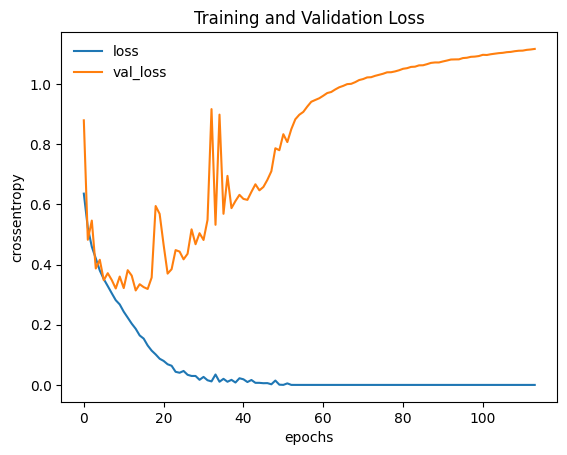

In [40]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False)  # 凡例（loss, val_loss）を表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")
plt.title("Training and Validation Loss")
plt.show()

In [41]:
# predictで予測を行なう
Y_pred = model.predict(X_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [42]:
Y_pred

array([[0.95975316],
       [0.96592903],
       [0.14269388],
       ...,
       [0.9834638 ],
       [0.69503856],
       [0.43082   ]], dtype=float32)

In [43]:
# 二値分類は予測結果の確率が0.5以下なら0,それより大きければ1となる計算で求める
Y_pred_classes = (Y_pred > 0.5).astype("int32")
Y_pred_classes

array([[1],
       [1],
       [0],
       ...,
       [1],
       [1],
       [0]], dtype=int32)

In [44]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_classes.reshape(-1)
Y_test_ = Y_test.reshape(-1)

In [45]:
# モデルの評価
from sklearn.metrics import classification_report

print(classification_report(Y_test_, Y_pred_))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1856
           1       0.85      0.89      0.87      1744

    accuracy                           0.87      3600
   macro avg       0.87      0.87      0.87      3600
weighted avg       0.87      0.87      0.87      3600

